### CAPSTONE | Recommend 2 Rolling Stones Albums to Boost Spotify Listener Engagement ###
*Caroline France prompted, edited, and revised content generated by Google Gemini.*

**Problem** | Spotify listeners face choice overload, with over 1,600 tracks available from The Rolling Stones.

**Process** | Analyze Spotify's Rolling Stones listeners' dataset to learn what Stones tracks and albums are popular among Spotify listeners. Use ML clustering, feature engineering, data visualization, and analysis to inform whole album recommendations and single tracks.

**Objectives**
- Recommend 2 Rolling Stones Albums for Today's Spotify Listeners
    - Group songs from **rolling_stones_spotify.csv** into distinct categories.
    - Analyze features from these groups against the entire catalog's popularity metrics to recommend 2 albums.

- Identify Listener Engagement Drivers & Patterns
    - Determine which **audio features** correlate with high **popularity** scores for Rolling Stones' songs on Spotify.

1. Import necessary Python libraries and dataset. Inspect data. Clean data. Find duplicates, missing values, irrelevant entries, and outliers. Check for instances of erroneous entries, and fix these.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.collections import LineCollection

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA

import os
os.environ["OMP_NUM_THREADS"] = "1"  # prevent issues with KMeans

import warnings
warnings.filterwarnings('ignore')

import seaborn as sns

BRAND_PALETTE = ['#D4AF37','#8B0000', "#878787", "#9A9999", '#E8E8E8']
sns.set_theme(style="white", context="paper", font_scale=1.2)
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=BRAND_PALETTE)

raw_df = pd.read_csv('rolling_stones_spotify.csv')

In [2]:
# Inspect the Original Dataset

print("\nMISSING VALUES")
print(raw_df.isnull().sum())

print("\nDUPLICATE ROWS")
print(raw_df.duplicated().sum())

print("ORIGINAL DATASET")
print(raw_df.info())

print("\nFIRST 2 ROWS")
print(raw_df.head(2))


MISSING VALUES
Unnamed: 0          0
name                0
album               0
release_date        0
track_number        0
id                  0
uri                 0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64

DUPLICATE ROWS
0
ORIGINAL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1610 non-null   int64  
 1   name              1610 non-null   object 
 2   album             1610 non-null   object 
 3   release_date      1610 non-null   object 
 4   track_number      1610 non-null   int64  
 5   id                1610 non-null   object 
 6   uri               1610 non-null   object 
 7   acous

In [3]:
# Data Cleaning
def ingest_and_clean_catalog(filepath: str) -> pd.DataFrame:
    raw_df = pd.read_csv(filepath)
    initial_record_count = len(raw_df)
    
    df_cleaned = raw_df.drop_duplicates(subset=['name', 'release_date'], keep='first').copy()
    df_cleaned = df_cleaned.dropna(subset=['id', 'name', 'popularity'])
    
    df_cleaned['release_date'] = pd.to_datetime(df_cleaned['release_date'], format='mixed', errors='coerce')
    df_cleaned = df_cleaned.dropna(subset=['release_date'])
    
    q1 = df_cleaned['duration_ms'].quantile(0.01)
    q3 = df_cleaned['duration_ms'].quantile(0.99)
    iqr = q3 - q1
    lower_bound = max(0, q1 - 1.5 * iqr)
    upper_bound = q3 + 1.5 * iqr
    
    valid_duration = (df_cleaned['duration_ms'] >= lower_bound) & (df_cleaned['duration_ms'] <= upper_bound)
    valid_popularity = (df_cleaned['popularity'] >= 0) & (df_cleaned['popularity'] <= 100)
    
    final_df = df_cleaned[valid_duration & valid_popularity].reset_index(drop=True)
    final_record_count = len(final_df)
    records_removed = initial_record_count - final_record_count
    
    print(f"Catalog Integrity Check Passed: \n- {initial_record_count} raw records ingested \n- {records_removed} invalid or duplicate entries purged \n- Final viable track count: {final_record_count}")
    
    return final_df

df_catalog = ingest_and_clean_catalog('rolling_stones_spotify.csv')

Catalog Integrity Check Passed: 
- 1610 raw records ingested 
- 367 invalid or duplicate entries purged 
- Final viable track count: 1243


In [4]:
print("Spotify's Rolling Stones Catalog Feature Values \n\n Avg.| Min | Max")
print(f"{df_catalog['energy'].mean():.2f}, {df_catalog['energy'].min():.2f}, {df_catalog['energy'].max():.2f} | Energy")
print(f"{df_catalog['valence'].mean():.2f}, {df_catalog['valence'].min():.2f}, {df_catalog['valence'].max():.2f} | Valence (Positivity)")
print(f"{df_catalog['liveness'].mean():.2f}, {df_catalog['liveness'].min():.2f}, {df_catalog['liveness'].max():.2f} | Liveness")
print(f"{df_catalog['danceability'].mean():.2f}, {df_catalog['danceability'].min():.2f}, {df_catalog['danceability'].max():.2f} | Danceability")
print(f"{df_catalog['acousticness'].mean():.2f}, {df_catalog['acousticness'].min():.2f}, {df_catalog['acousticness'].max():.2f} | Acousticness")
print(f"{df_catalog['instrumentalness'].mean():.2f}, {df_catalog['instrumentalness'].min():.2f}, {df_catalog['instrumentalness'].max():.2f} | Instrumentalness")
print(f"{df_catalog['speechiness'].mean():.2f}, {df_catalog['speechiness'].min():.2f}, {df_catalog['speechiness'].max():.2f} | Speechiness")
print(f"{df_catalog['loudness'].mean():.1f}, {df_catalog['loudness'].min():.1f}, {df_catalog['loudness'].max():.1f} | Loudness")
print(f"  {df_catalog['popularity'].mean():.0f},     {df_catalog['popularity'].min():.0f},  {df_catalog['popularity'].max():.0f} | Popularity")
print(f" {df_catalog['tempo'].mean():.0f},    {df_catalog['tempo'].min():.0f}, {df_catalog['tempo'].max():.0f} | Tempo (Moderately Fast Beat)")
direct_average = int(round(df_catalog['release_date'].dt.year.mean()))
print(f"{direct_average} | Year of Release")

Spotify's Rolling Stones Catalog Feature Values 

 Avg.| Min | Max
0.81, 0.14, 1.00 | Energy
0.56, 0.00, 0.97 | Valence (Positivity)
0.53, 0.02, 1.00 | Liveness
0.46, 0.10, 0.89 | Danceability
0.24, 0.00, 0.99 | Acousticness
0.15, 0.00, 1.00 | Instrumentalness
0.07, 0.02, 0.62 | Speechiness
-6.7, -24.4, -1.0 | Loudness
  22,     0,  80 | Popularity
 126,    47, 216 | Tempo (Moderately Fast Beat)
1995 | Year of Release


2. Based on findings in step 1, refine data for further processing.

**Feature Engineering & Catalog Refinement**
- Track feature changes from 1960 to present.
- Evaluate the preference for live or studio recordings.
- Find the range of song length that today's Spotify listeners prefer.

In [5]:
# FEATURE ENGINEERING
def engineer_catalog_features(df: pd.DataFrame) -> pd.DataFrame:
    df_engineered = df.copy()
    
    df_engineered['release_year'] = df_engineered['release_date'].dt.year    
    bins = [1960, 1970, 1980, 1990, 2000, 2010, 2030]
    labels = ['1960s', '1970s', '1980s', '1990s', '2000s', 'Modern Era']
    df_engineered['catalog_era'] = pd.cut(df_engineered['release_year'], bins=bins, labels=labels, right=False)
    
    # Identify & separate live performances from studio recordings.
    live_name_mask = df_engineered['name'].str.contains(r'(?i)\b(live|concert)\b', na=False)
    live_audio_mask = df_engineered['liveness'] > 0.8
    df_engineered['is_live'] = np.where(live_name_mask | live_audio_mask, 1, 0)

# DATA TRANSFORMATION
    # Convert 'duration' milliseconds to minutes, to identify song length popularity
    df_engineered['duration_minutes'] = df_engineered['duration_ms'] / 60000
    
    columns_to_drop = ['duration_ms'] 
    df_engineered = df_engineered.drop(columns=[col for col in columns_to_drop if col in df_engineered.columns])
    
    # Normalize 'popularity' from 0-80 to a 0-1 scale
    df_engineered['popularity'] = (df_engineered['popularity'] - df_engineered['popularity'].min()) / (df_engineered['popularity'].max() - df_engineered['popularity'].min())

    # Create semantic bins for 'loudness' from a negative scale to categories
    df_engineered['loudness_category'] = pd.cut(df_engineered['loudness'], bins=[-60, -30, -10, 0, 10], labels=['Very Quiet', 'Quiet', 'Moderate', 'Loud'])

    return df_engineered

df_engineered = engineer_catalog_features(df_catalog)

3. Exploratory Data Analysis & Feature Engineering

- **Decision Boundary** | Calculate how many groups (distinct cohorts) the dataset should be split into.

- **Visualizations** | Identify 2 albums that should be recommended to anyone based on the number of popular songs in each album.

- **Exploratory Data Analysis** | Find features of songs to identify popularity patterns.

- **Correlation** | Examine the relationship between a song's popularity and other factors. Explore how this correlation evolved.

- **Insights** | Note the significance of dimensionality reduction techniques.

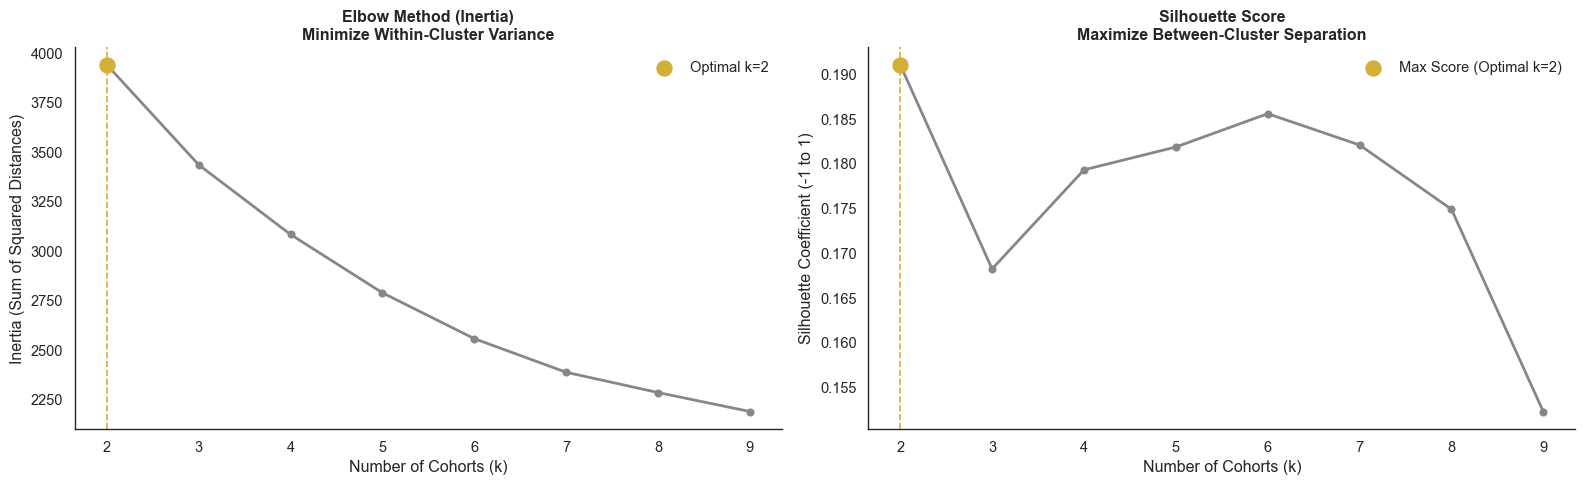

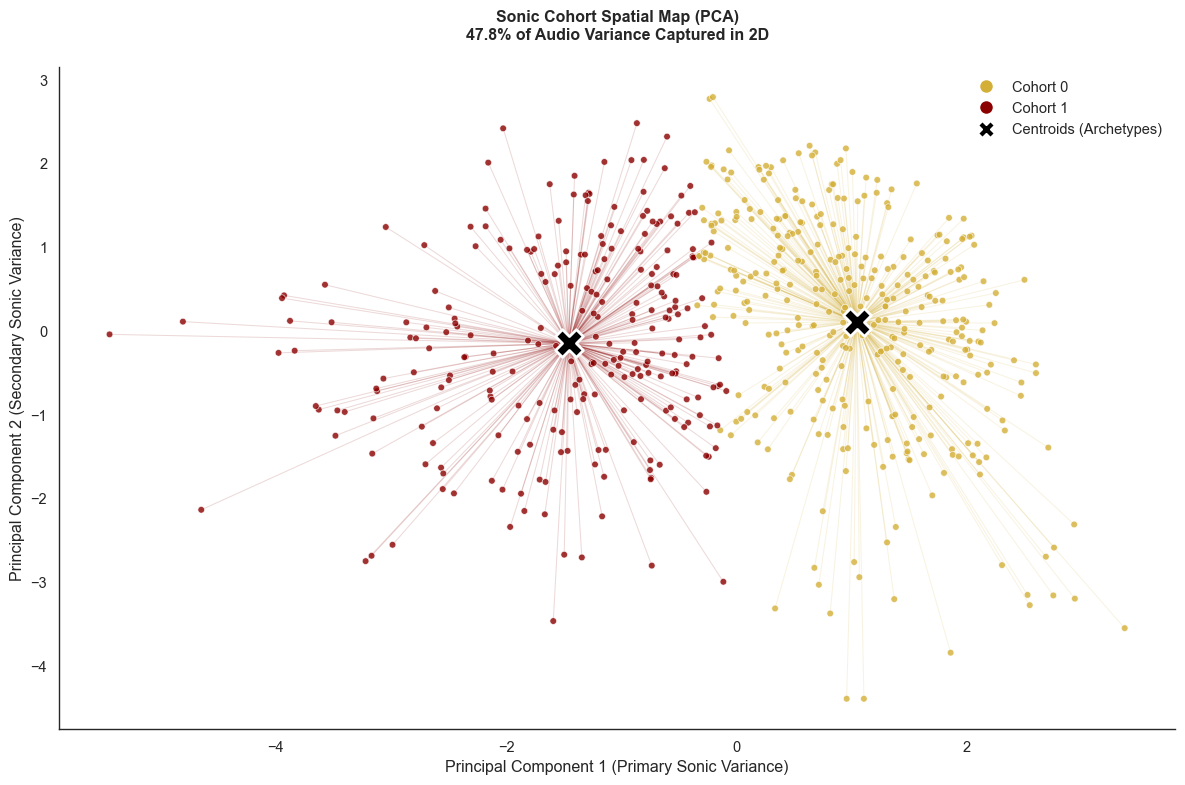

In [6]:

# DECISION BOUNDARY: Determine the optimal number of clusters for the K-Means algorithm
def optimize_and_visualize_clusters(df: pd.DataFrame):
    analysis_df = df[df['is_live'] == 0].copy()
    features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'tempo']
    
    X = analysis_df[features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    k_range = range(2, 10)
    inertia = []
    silhouette_scores = []
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        inertia.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
        
# Place marker on line to emphasize max value
    optimal_index = np.argmax(silhouette_scores)
    optimal_k = k_range[optimal_index]
    optimal_inertia = inertia[optimal_index]
    max_silhouette = silhouette_scores[optimal_index]

# VISUALIZATION I | Elbow     
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(k_range, inertia, marker='o', color=BRAND_PALETTE[2], linewidth=2)
    axes[0].axvline(x=optimal_k, color=BRAND_PALETTE[0], linestyle='--')
    axes[0].scatter(optimal_k, optimal_inertia, color=BRAND_PALETTE[0], s=120, zorder=5, label=f'Optimal k={optimal_k}')
    
    axes[0].set_title('Elbow Method (Inertia)\nMinimize Within-Cluster Variance', weight='bold')
    axes[0].set_xlabel('Number of Cohorts (k)')
    axes[0].set_ylabel('Inertia (Sum of Squared Distances)')
    axes[0].legend(frameon=False)
    sns.despine(ax=axes[0])

# VISUALIZATION II | Silhouette
    axes[1].plot(k_range, silhouette_scores, marker='o', color=BRAND_PALETTE[2], linewidth=2)
    axes[1].axvline(x=optimal_k, color=BRAND_PALETTE[0], linestyle='--')
    axes[1].scatter(optimal_k, max_silhouette, color=BRAND_PALETTE[0], s=120, zorder=5, label=f'Max Score (Optimal k={optimal_k})')
    
    axes[1].set_title('Silhouette Score\nMaximize Between-Cluster Separation', weight='bold')
    axes[1].set_xlabel('Number of Cohorts (k)')
    axes[1].set_ylabel('Silhouette Coefficient (-1 to 1)')
    axes[1].legend(frameon=False)
    sns.despine(ax=axes[1])

    plt.tight_layout()
    plt.show()
    
    final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    cluster_labels = final_kmeans.fit_predict(X_scaled)
    analysis_df['cohort'] = cluster_labels

# PCA: Reduce dimensionality for visualization
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    centroids_pca = pca.transform(final_kmeans.cluster_centers_)

# VISUALIZATION III | Scatter Plot
    fig_scatter, ax_scatter = plt.subplots(figsize=(12, 8))
    
    spoke_lines = []
    spoke_colors = []
    for i in range(len(X_pca)):
        cluster_idx = cluster_labels[i]
        point_coords = X_pca[i]
        centroid_coords = centroids_pca[cluster_idx]
        
        spoke_lines.append([point_coords, centroid_coords])
        spoke_colors.append(BRAND_PALETTE[cluster_idx])
        
    line_collection = LineCollection(spoke_lines, colors=spoke_colors, alpha=0.15, linewidths=0.75, zorder=1)
    ax_scatter.add_collection(line_collection)
    
# Song/track data points
    sns.scatterplot(
        x=X_pca[:, 0], 
        y=X_pca[:, 1], 
        hue=cluster_labels, 
        palette=BRAND_PALETTE[:optimal_k], 
        alpha=0.8, 
        edgecolor='white',
        linewidth=0.5,
        ax=ax_scatter,
        legend=False,
        zorder=5 
    )
    
# Centroid - shows the most representative song differences in each of the 2 cohorts
    ax_scatter.scatter(
        centroids_pca[:, 0], 
        centroids_pca[:, 1], 
        marker='X', 
        s=400, 
        c='black', 
        edgecolors='white',
        linewidths=2,
        zorder=10
    )
    
    variance_explained = sum(pca.explained_variance_ratio_) * 100
    ax_scatter.set_title(f'Sonic Cohort Spatial Map (PCA)\n{variance_explained:.1f}% of Audio Variance Captured in 2D', weight='bold', pad=20)
    ax_scatter.set_xlabel('Principal Component 1 (Primary Sonic Variance)')
    ax_scatter.set_ylabel('Principal Component 2 (Secondary Sonic Variance)')
    
# Custom Legend
    legend_elements = [
        mlines.Line2D([0], [0], marker='o', color='w', label=f'Cohort {i}', 
                      markerfacecolor=BRAND_PALETTE[i], markersize=10) for i in range(optimal_k)
    ]
    legend_elements.append(
        mlines.Line2D([0], [0], marker='X', color='w', label='Centroids (Archetypes)', 
                      markerfacecolor='black', markeredgecolor='white', markersize=12)
    )
    
    ax_scatter.legend(handles=legend_elements, frameon=False, loc='upper right')
    sns.despine(ax=ax_scatter)
    
    plt.tight_layout()
    plt.show()

    return analysis_df, final_kmeans

df_clustered, model_kmeans = optimize_and_visualize_clusters(df_engineered)

The **elbow method** & **silhouette score** both differentiate Stones' songs into 2 groups: Cohort 0 & Cohort 1. Each cohort includes a group of sonic features with different values. Here are their values:

In [7]:
def define_sonic_cohorts(df: pd.DataFrame, model_kmeans: KMeans):
    features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'tempo']
    
    scaler = StandardScaler()
    scaler.fit(df[features])
    
    cohort_profiles = df.groupby('cohort')[features].mean()
    
    cohort_sizes = df['cohort'].value_counts().sort_index()
    cohort_profiles.insert(0, 'track_count', cohort_sizes)

    print("SONIC COHORT DEFINITIONS | AVERAGE AUDIO FEATURES")
    #print("\n")
    print(cohort_profiles.round(3).to_string())

    X_scaled = scaler.transform(df[features])
    centroids = model_kmeans.cluster_centers_
    distances = pairwise_distances(X_scaled, centroids)
    
    print("="*115)
    print("COHORT ARCHETYPES | SONGS CLOSEST TO THE CENTROID OF EACH COHORT")
    
    for i in range(model_kmeans.n_clusters):
        cohort_distances = distances[:, i]
        cohort_indices = np.where(df['cohort'] == i)[0]
        
        closest_indices = cohort_indices[np.argsort(cohort_distances[cohort_indices])[:3]]
        archetype_tracks = df.iloc[closest_indices][['name', 'album', 'release_year']]
        
        print(f"\n--- Cohort {i} Archetypes ---")
        for _, row in archetype_tracks.iterrows():
            print(f"• {row['name']} (Album: {row['album']}, {row['release_year']})")

define_sonic_cohorts(df_clustered, model_kmeans)

SONIC COHORT DEFINITIONS | AVERAGE AUDIO FEATURES
        track_count  danceability  energy  loudness  speechiness  acousticness  instrumentalness  valence    tempo
cohort                                                                                                            
0               358         0.546   0.843    -6.181        0.060         0.174             0.218    0.755  129.703
1               253         0.509   0.557    -9.721        0.043         0.407             0.107    0.504  115.086
COHORT ARCHETYPES | SONGS CLOSEST TO THE CENTROID OF EACH COHORT

--- Cohort 0 Archetypes ---
• Slave - Remastered (Album: Tattoo You (2009 Re-Mastered), 1981)
• Slave - Remastered 2021 (Album: Tattoo You (Super Deluxe), 2021)
• Just Your Fool (Album: Honk (Deluxe), 2019)

--- Cohort 1 Archetypes ---
• Time Is On My Side - Mono Version (Album: The Rolling Stones No. 2, 1965)
• New Faces - Remastered (Album: Voodoo Lounge (Remastered 2009), 1994)
• If You Need Me (Album: 12 x 5, 1964)


<table style="border: none; border-collapse: collapse; width: 90%;">
<thead>
    <tr>
        <th style="border: none;">Differences</th>
        <th style="border: none; text-align: center;">Cohort 0</th>
        <th style="border: none; text-align: center;">Cohort 1</th>
    </tr>
</thead>
<tr>
    <td style="border: none;">Sound</td>
    <td style="border: none; text-align: center;">Modern, edgy groove</td>
    <td style="border: none; text-align: center;">Classic, early 1960s</td>
</tr>
<tr>
    <td style="border: none;">Rhythm</td>
    <td style="border: none; text-align: center;">Prevalent drums, syncopation/off beat, driving beat</td>
    <td style="border: none; text-align: center;">Consistent, slow-to-mid-tempo, shuffle-blues beat</td>
</tr>
<tr>
    <td style="border: none;">Vocals</td>
    <td style="border: none; text-align: center;">Gritty, Mick's scream and attitude, layered backup vocals are independent of the lead vocal</td>
    <td style="border: none; text-align: center;">Melodic, innocent, harmony pairs the lead vocal, spoken word breaks</td>
</tr>
<tr>
    <td style="border: none;">Instruments</td>
    <td style="border: none; text-align: center;">Drum kit, electric guitar, keys, saxophone, harmonica</td>
    <td style="border: none; text-align: center;">Tambourine, guitar, minimal drum with high hat, harpsichord</td>
</tr>
<tr>
    <td style="border: none;">Environment</td>
    <td style="border: none; text-align: center;">Gritty, lively, modern bar at night</td>
    <td style="border: none; text-align: center;">Bright, Sunday stroll</td>
</tr>
<tr>
    <td style="border: none;">Centroid Examples</td>
    <td style="border: none; text-align: center;"><a href="https://www.youtube.com/watch?v=yU2Gv9UoL7E&list=PLP7u94NwnE9y-3zrDcjK66jCcNU8wm_0U&index=20">"Just Your Fool"</a> & <a href="https://www.youtube.com/watch?v=UCPXRikOaeE&list=PLd-uR9E1IqHT_bJ9Bdy7becXyvDmMzbiz&index=5">"Slave"</a></td>
    <td style="border: none; text-align: center;"><a href="https://www.youtube.com/watch?v=7CQrciAJ618&list=RD7CQrciAJ618&start_radio=1">"New Faces"</a> & <a href="https://www.youtube.com/watch?v=ZHKz7FBUF1w&list=RDZHKz7FBUF1w&start_radio=1">"Time Is On My Side"</a></td>
</tr>
</table>

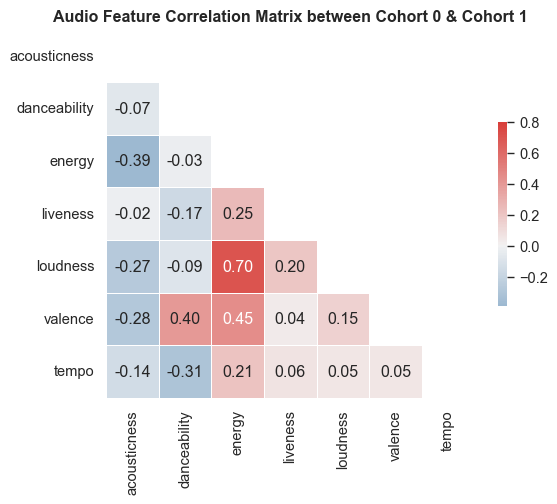

In [8]:
def perform_exploratory_analysis(df: pd.DataFrame):
    fig = plt.figure(figsize=(11, 9))
    
    # 3b. Feature Relationship Mapping
    ax2 = plt.subplot(2, 2, 2)
    audio_features = ['acousticness', 'danceability', 'energy', 'liveness', 'loudness', 'valence', 'tempo']
    corr_matrix = df[audio_features].corr()
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    cmap = sns.diverging_palette(243, 13, as_cmap=True)
    sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=.8, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True, fmt=".2f", ax=ax2)
    ax2.set_title('Audio Feature Correlation Matrix between Cohort 0 & Cohort 1', weight='bold')
    
    plt.tight_layout()
    plt.show()

perform_exploratory_analysis(df_clustered)

**Strongest Correlations Between Features**
1. 70% Energy & Loudness
2. 55% Danceability & Valence (positivity)
3. 53% Energy & Liveness (played live in-person or recorded in a studio)

Note: Focus on Energy & Valence

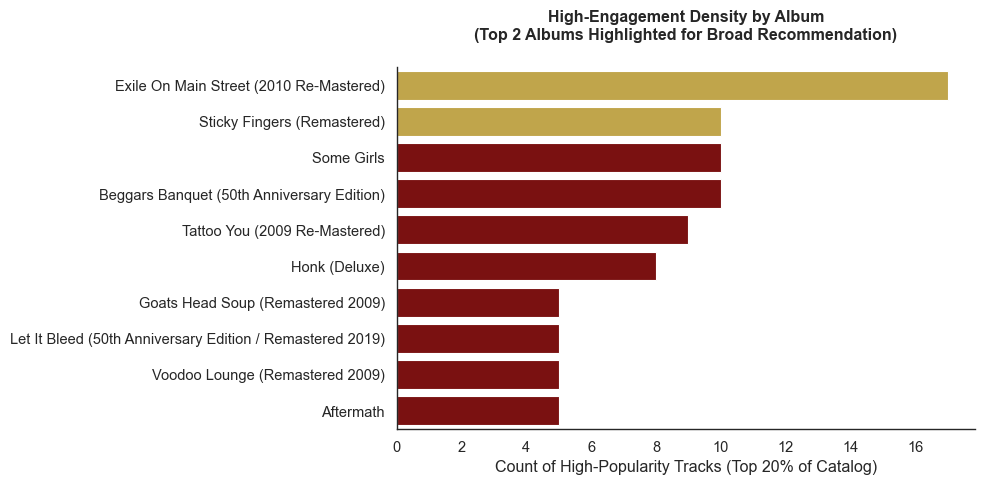

In [9]:
# 3 a. Identify Top 2 Albums for Broad Recommendation
def visualize_album_recommendations(df: pd.DataFrame):
    popularity_threshold = df['popularity'].quantile(0.80)
    popular_tracks = df[df['popularity'] >= popularity_threshold]
    
    album_engagement = popular_tracks.groupby('album').size().sort_values(ascending=False).head(10)
    
    highlight_colors = [BRAND_PALETTE[0] if i < 2 else BRAND_PALETTE[1] for i in range(len(album_engagement))]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=album_engagement.values, y=album_engagement.index, palette=highlight_colors, ax=ax)
    
    ax.set_title('High-Engagement Density by Album\n(Top 2 Albums Highlighted for Broad Recommendation)', weight='bold', pad=20)
    ax.set_xlabel('Count of High-Popularity Tracks (Top 20% of Catalog)')
    ax.set_ylabel('')
    sns.despine()
    plt.tight_layout()
    plt.show()

visualize_album_recommendations(df_clustered)

In [10]:
# Mathematically confirm which 1 of the 3 albums tied for second place is the most popular
tied_albums = [
    'Sticky Fingers (Remastered)', 
    'Some Girls', 
    'Beggars Banquet (50th Anniversary Edition)'
]

tied_data = df_clustered[df_clustered['album'].isin(tied_albums)]

tie_breaker_stats = tied_data.groupby('album').agg(
    Total_Tracks=('name', 'count'),
    Average_Popularity=('popularity', 'mean'),
    Sum_Popularity=('popularity', 'sum')
).sort_values(by='Average_Popularity', ascending=False)

print("\n--- TIE-BREAKER MATH ---")
print(tie_breaker_stats.round(2).to_string())


--- TIE-BREAKER MATH ---
                                            Total_Tracks  Average_Popularity  Sum_Popularity
album                                                                                       
Sticky Fingers (Remastered)                           10                0.67            6.66
Some Girls                                            10                0.60            6.01
Beggars Banquet (50th Anniversary Edition)            10                0.55            5.46


**Top 2 Recommended Rolling Stones' Albums (Overall) for Spotify Listeners**

1. <a href="https://www.youtube.com/playlist?list=PL4cFJtUcmjZkHMqy2mjmjUlsZzdypKdE6">Exile on Main Street (2010 Remastered)</a>

2. <a href="https://www.youtube.com/watch?v=rv3cLBVQiK8&list=PLA9-lU434qdt8idu042MMGOC1iyOTvg48">Sticky Fingers (2009 Remastered)</a>

Here are factors that support the selection of these albums:

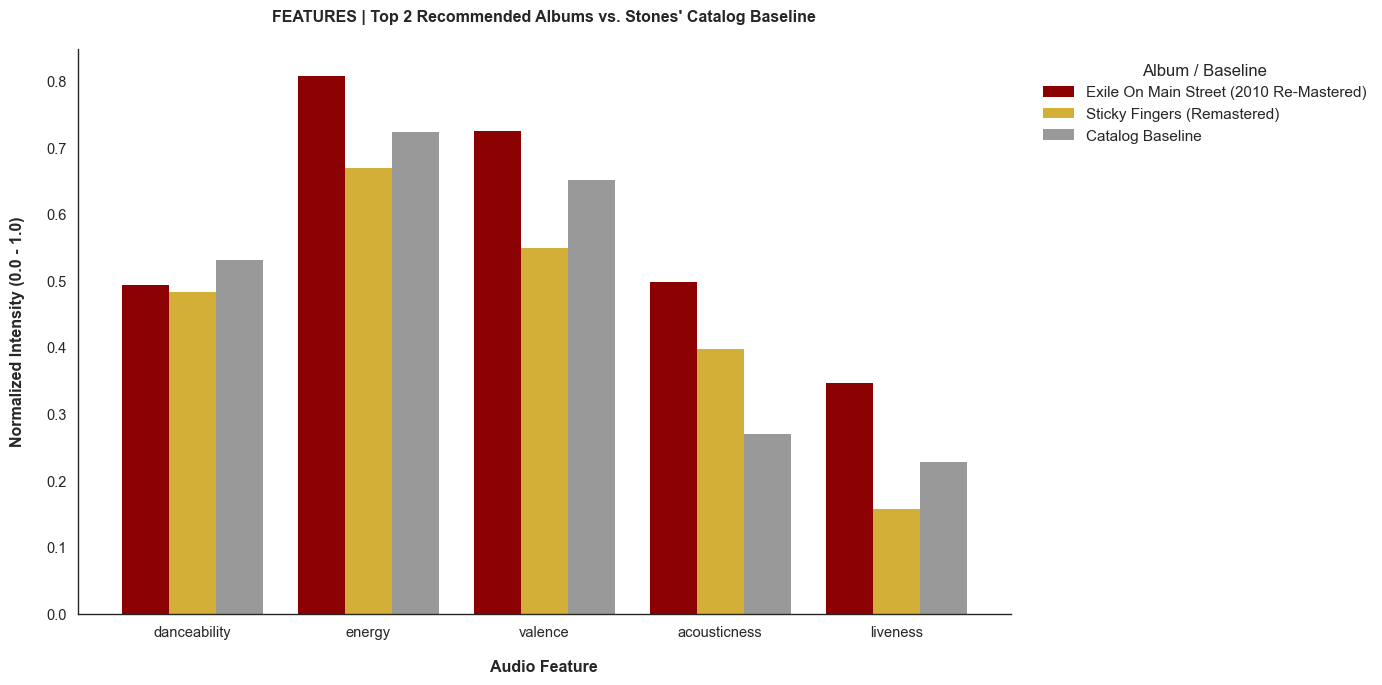

In [11]:
def visualize_album_signatures(df: pd.DataFrame):
    popularity_threshold = df['popularity'].quantile(0.80)
    popular_tracks = df[df['popularity'] >= popularity_threshold]
    
    album_metrics = popular_tracks.groupby('album').agg(
        hit_count=('name', 'count'),
        avg_popularity=('popularity', 'mean')
    ).sort_values(by=['hit_count', 'avg_popularity'], ascending=[False, False])

    top_album_names = album_metrics.head(2).index.tolist()
    
    features = ['danceability', 'energy', 'valence', 'acousticness', 'liveness']

    album_1_stats = df[df['album'] == top_album_names[0]][features].mean()
    album_2_stats = df[df['album'] == top_album_names[1]][features].mean()
    catalog_stats = df[features].mean()
    
    plot_df = pd.DataFrame({
        top_album_names[0]: album_1_stats,
        top_album_names[1]: album_2_stats,
        'Catalog Baseline': catalog_stats
    })

    fig, ax = plt.subplots(figsize=(14, 7))

    bar_colors = [BRAND_PALETTE[1], BRAND_PALETTE[0], BRAND_PALETTE[3]]

    plot_df.plot(kind='bar', ax=ax, color=bar_colors, width=0.8, edgecolor='none')

    ax.set_title('FEATURES | Top 2 Recommended Albums vs. Stones\' Catalog Baseline', weight='bold', pad=20)
    ax.set_xlabel('Audio Feature', weight='bold', labelpad=15)
    ax.set_ylabel('Normalized Intensity (0.0 - 1.0)', weight='bold', labelpad=15)

    plt.xticks(rotation=0)

    ax.legend(
        title='Album / Baseline', 
        bbox_to_anchor=(1.02, 1), 
        loc='upper left', 
        frameon=False,
        fontsize=11,
        title_fontsize=12
    )
    
    sns.despine()
    plt.tight_layout()
    plt.show()

visualize_album_signatures(df_clustered)

**Support for Album Recommendations**: The 2 recommended albums are close to the Spotify Stones' catalog baseline values for **popularity** for salient features: energy, danceability, and valence.

#### Patterns ####

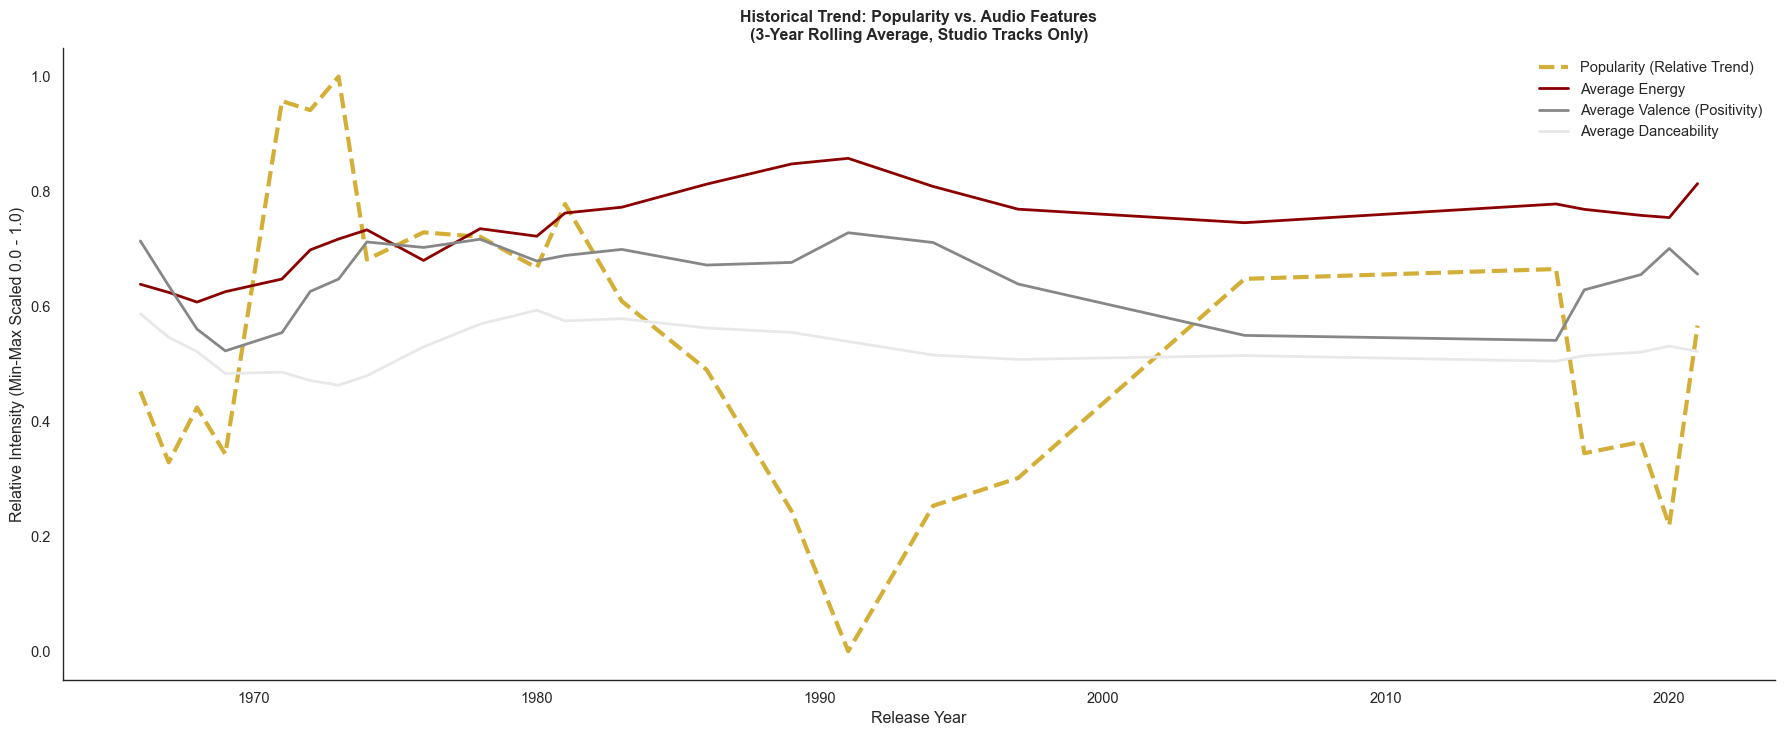

In [12]:
def perform_exploratory_analysis(df: pd.DataFrame):
    fig = plt.figure(figsize=(18, 14))
    
    # 3c. Engagement Evolution Over Time
    ax3 = plt.subplot(2, 1, 2)
    studio_tracks = df[df['is_live'] == 0]
    
    yearly_metrics = studio_tracks.groupby('release_year')[['popularity', 'energy', 'valence', 'danceability']].mean().rolling(window=3).mean()
    
    # MIN-MAX NORMALIZATION
    # Stretch Popularity to span the full 0.0 - 1.0 visual space
    min_pop = yearly_metrics['popularity'].min()
    max_pop = yearly_metrics['popularity'].max()
    yearly_metrics['popularity_normalized'] = (yearly_metrics['popularity'] - min_pop) / (max_pop - min_pop)
    
    sns.lineplot(data=yearly_metrics, x=yearly_metrics.index, y='popularity_normalized', label='Popularity (Relative Trend)', color=BRAND_PALETTE[0], linewidth=3, linestyle='--', ax=ax3)
    sns.lineplot(data=yearly_metrics, x=yearly_metrics.index, y='energy', label='Average Energy', color=BRAND_PALETTE[1], linewidth=2, ax=ax3)
    sns.lineplot(data=yearly_metrics, x=yearly_metrics.index, y='valence', label='Average Valence (Positivity)', color=BRAND_PALETTE[2], linewidth=2, ax=ax3)
    sns.lineplot(data=yearly_metrics, x=yearly_metrics.index, y='danceability', label='Average Danceability', color=BRAND_PALETTE[4], linewidth=2, ax=ax3)
    
    ax3.set_title('Historical Trend: Popularity vs. Audio Features\n(3-Year Rolling Average, Studio Tracks Only)', weight='bold')
    ax3.set_xlabel('Release Year')
    ax3.set_ylabel('Relative Intensity (Min-Max Scaled 0.0 - 1.0)')
    ax3.legend(frameon=False)
    sns.despine(ax=ax3)
    
    plt.tight_layout()
    plt.show()

perform_exploratory_analysis(df_engineered)

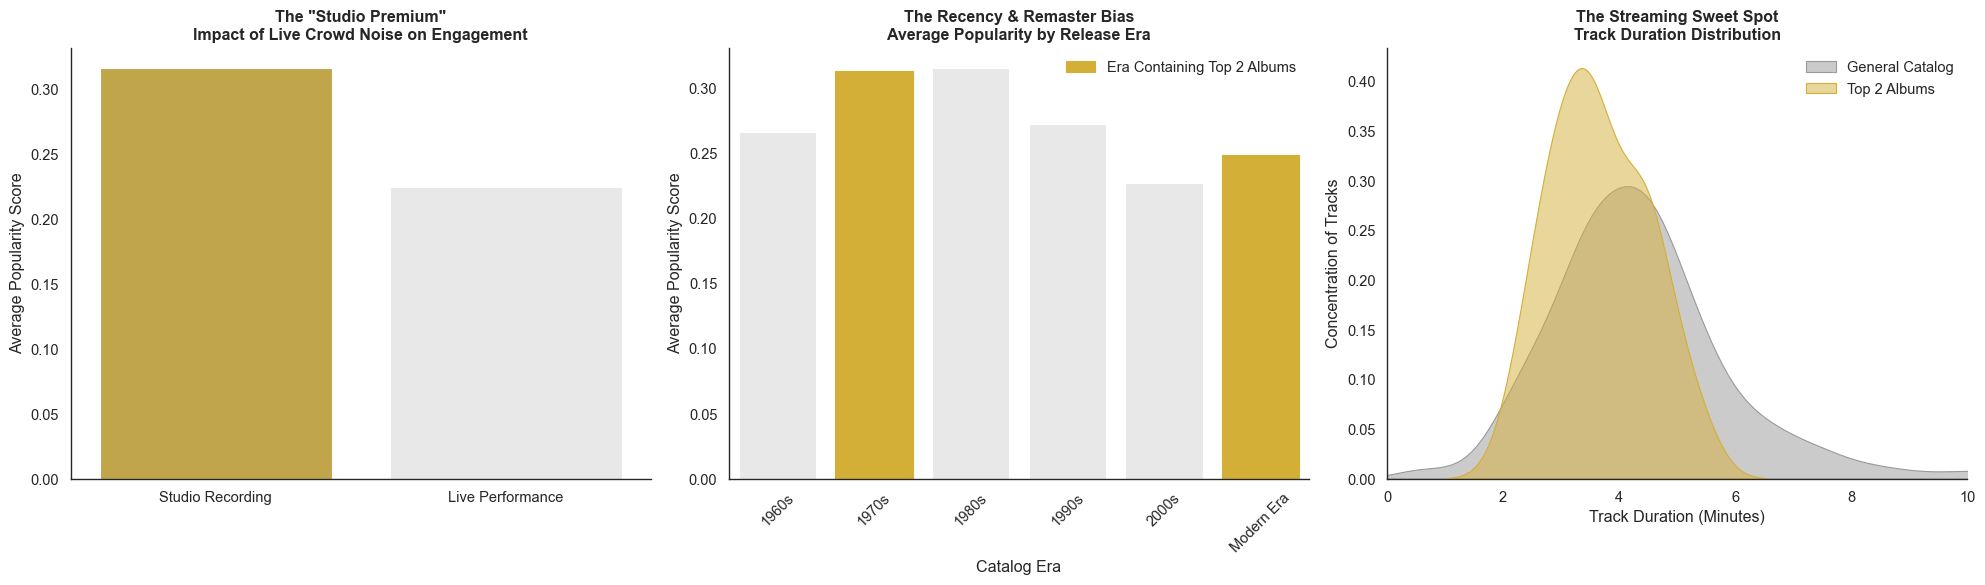

In [13]:
def visualize_engineered_drivers(df: pd.DataFrame):
    popularity_threshold = df['popularity'].quantile(0.80)
    popular_tracks = df[df['popularity'] >= popularity_threshold]
    top_albums = popular_tracks.groupby('album').size().nlargest(2).index.tolist()
    
    df_plot = df.copy()
    df_plot['album_group'] = np.where(df_plot['album'].isin(top_albums), 'Top 2 Recommended Albums', 'General Catalog')
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    sns.barplot(
        data=df_plot, 
        x='is_live', 
        y='popularity', 
        palette=[BRAND_PALETTE[0], BRAND_PALETTE[4]],
        errorbar=None,
        ax=axes[0]
    )
    axes[0].set_xticklabels(['Studio Recording', 'Live Performance'])
    axes[0].set_title('The "Studio Premium"\nImpact of Live Crowd Noise on Engagement', weight='bold')
    axes[0].set_ylabel('Average Popularity Score')
    axes[0].set_xlabel('')
    sns.despine(ax=axes[0])
    
    sns.barplot(
        data=df_plot, 
        x='catalog_era', 
        y='popularity', 
        color=BRAND_PALETTE[4], 
        errorbar=None,
        ax=axes[1]
    )
    
    top_eras = df_plot[df_plot['album_group'] == 'Top 2 Recommended Albums']['catalog_era'].unique()
    for i, bar in enumerate(axes[1].patches):
        era_label = df_plot['catalog_era'].cat.categories[i]
        if era_label in top_eras:
            bar.set_color(BRAND_PALETTE[0]) 
            
    axes[1].set_title('The Recency & Remaster Bias\nAverage Popularity by Release Era', weight='bold')
    axes[1].set_xlabel('Catalog Era')
    axes[1].set_ylabel('Average Popularity Score')
    axes[1].tick_params(axis='x', rotation=45)
    
    import matplotlib.patches as mpatches
    gold_patch = mpatches.Patch(color=BRAND_PALETTE[0], label='Era Containing Top 2 Albums')
    axes[1].legend(handles=[gold_patch], frameon=False, loc='upper right')
    sns.despine(ax=axes[1])
    
    sns.kdeplot(
        data=df_plot[df_plot['album_group'] == 'General Catalog'], 
        x='duration_minutes', 
        color=BRAND_PALETTE[3], 
        fill=True, 
        alpha=0.5,
        label='General Catalog', 
        ax=axes[2]
    )
    sns.kdeplot(
        data=df_plot[df_plot['album_group'] == 'Top 2 Recommended Albums'], 
        x='duration_minutes', 
        color=BRAND_PALETTE[0], 
        fill=True, 
        alpha=0.5,
        label='Top 2 Albums', 
        ax=axes[2]
    )
    axes[2].set_title('The Streaming Sweet Spot\nTrack Duration Distribution', weight='bold')
    axes[2].set_xlabel('Track Duration (Minutes)')
    axes[2].set_ylabel('Concentration of Tracks')
    axes[2].set_xlim(0, 10) 
    axes[2].legend(frameon=False)
    sns.despine(ax=axes[2])
    
    plt.tight_layout()
    plt.show()

visualize_engineered_drivers(df_engineered)

**Stones' Popularity Patterns Found** | *Features that Impact Popularity of Stones' Tracks*

*Left Chart* | Studio vs. Live
- **Studio recordings** are more popular than live recordings.
- Both recommended top albums are studio recordings.

*Middle Chart* | Popularity by Era
- Although the Rolling Stones experienced peak popularity in the 1970s, today's Spotify listeners engage most with **Modern remasters**.
- Both recommended top albums are in the "Modern Era" bucket (gold)
    - *Exile on Main Street*, released in 1972, remastered in 2010
    - *Sticky Fingers*, released in 1971, remastered in 2015

*Right Chart* | Track Duration Popularity
- The gold peak (top 2 albums) is tightly clustered around **3** to **4.5 minutes**.

In [14]:
def extract_hero_tracks(df: pd.DataFrame, top_n_per_album: int = 3):
    popularity_threshold = df['popularity'].quantile(0.80)
    popular_tracks = df[df['popularity'] >= popularity_threshold]
    
    # NEW LOGIC: Count hits, average popularity, and sort both to break ties
    album_metrics = popular_tracks.groupby('album').agg(
        hit_count=('name', 'count'),
        avg_popularity=('popularity', 'mean')
    ).sort_values(by=['hit_count', 'avg_popularity'], ascending=[False, False])

    top_album_names = album_metrics.head(2).index.tolist()
    
    target_albums_df = df[df['album'].isin(top_album_names)].copy()
    
    sorted_albums_df = target_albums_df.sort_values(by=['album', 'popularity'], ascending=[True, False])
    
    hero_tracks = sorted_albums_df.groupby('album').head(top_n_per_album)
    
    print(f"HERO TRACKS: TOP {top_n_per_album} MOST POPULAR SONGS PER RECOMMENDED ALBUM")
    
    for album in top_album_names:
        print(f"\nAlbum | {album}")
        album_data = hero_tracks[hero_tracks['album'] == album]
        
        for index, row in album_data.iterrows():
            print(f" • {row['name']} | Popularity: {row['popularity']:.2f}")

extract_hero_tracks(df_clustered, top_n_per_album=3)

HERO TRACKS: TOP 3 MOST POPULAR SONGS PER RECOMMENDED ALBUM

Album | Exile On Main Street (2010 Re-Mastered)
 • Tumbling Dice | Popularity: 0.79
 • Sweet Virginia | Popularity: 0.70
 • Shine A Light | Popularity: 0.66

Album | Sticky Fingers (Remastered)
 • Wild Horses - 2009 Mix | Popularity: 0.86
 • Brown Sugar - 2009 Remaster | Popularity: 0.82
 • Can't You Hear Me Knocking - 2009 Mix | Popularity: 0.79


Listen to the 3 most popular songs from the 2 most recommended overall albums here:

<table style="border: none; border-collapse: collapse; width: 90%;">
<thead>
    <th style="border: none; text-align: center;"><img src="exile-on-main-st.jpeg" alt="Exile On Main Street" width="300" height="300"></th>
    <th style="border: none; text-align: center;"><img src="sticky_fingers.jpg" alt="Sticky Fingers" width="300" height="300"></th>
</thead>
<tr>
    <td style="border: none; text-align: center;"><i>Exile On Main Street</i></td>
    <td style="border: none; text-align: center;"><i>Sticky Fingers</i></td>
</tr>
<tr>
    <td style="border: none; text-align: center;"><a href="https://www.youtube.com/watch?v=q0IHiui374U&list=PL4cFJtUcmjZkHMqy2mjmjUlsZzdypKdE6&index=5">Tumbling Dice</a></td>
    <td style="border: none; text-align: center;"><a href="https://www.youtube.com/watch?v=lJD2OtTaywo&list=RDlJD2OtTaywo&start_radio=1">Wild Horses</a></td>
</tr>
<tr>
    <td style="border: none; text-align: center;"><a href="https://www.youtube.com/watch?v=5AH8Wu63hg4&list=PL4cFJtUcmjZkHMqy2mjmjUlsZzdypKdE6&index=6">Sweet Virginia</a></td>
    <td style="border: none; text-align: center;"><a href="https://www.youtube.com/watch?v=Bar7SzNLnY0&list=RDBar7SzNLnY0&start_radio=1">Brown Sugar</a></td>
</tr>
<tr>
    <td style="border: none; text-align: center;"><a href="https://www.youtube.com/watch?v=UgPdCdzTbI8&list=PL4cFJtUcmjZkHMqy2mjmjUlsZzdypKdE6&index=17">Shine A Light</a></td>
    <td style="border: none; text-align: center;"><a href="https://www.youtube.com/watch?v=nkQ0LhcTNsY&list=RDnkQ0LhcTNsY&start_radio=1">Can't You Hear Me Knocking</a></td>
</tr>
</table>

#### All-Time Greatest Hits ####

In [15]:
# Extract and print the most popular tracks from the entire catalog.
def extract_top_catalog_tracks(df: pd.DataFrame, top_n: int = 10):
    # Sort the dataframe by popularity in descending order and grab the top N rows
    top_tracks = df.sort_values(by='popularity', ascending=False).head(top_n)
    
    print(f"TOP {top_n} MOST POPULAR ROLLING STONES TRACKS (ENTIRE CATALOG)\n")
    print("Popularity | Track Name (Album, Release Year)")
    print("-" * 50)
    # Use enumerate to create a clean 1 through 10 ranking in the printout
    for rank, (_, row) in enumerate(top_tracks.iterrows(), start=1):
        # Checking if release_year exists depending on which step of the pipeline you run this in
        year_str = f", {row['release_year']}" if 'release_year' in row else ""
        
        print(f"{row['popularity']:.2f} | {rank}. {row['name']} (Album: {row['album']}{year_str})")

# --- Top Tracks ---
extract_top_catalog_tracks(df_engineered, top_n=10)

TOP 10 MOST POPULAR ROLLING STONES TRACKS (ENTIRE CATALOG)

Popularity | Track Name (Album, Release Year)
--------------------------------------------------
1.00 | 1. Paint It, Black (Album: Aftermath, 1966)
0.95 | 2. (I Can't Get No) Satisfaction - Mono Version (Album: Out Of Our Heads, 1965)
0.95 | 3. Start Me Up - Remastered 2009 (Album: Tattoo You (2009 Re-Mastered), 1981)
0.91 | 4. Sympathy For The Devil - 50th Anniversary Edition (Album: Beggars Banquet (50th Anniversary Edition), 1968)
0.90 | 5. Beast Of Burden - Remastered 1994 (Album: Some Girls, 1978)
0.89 | 6. Angie (Album: Goats Head Soup (Remastered 2009), 1973)
0.86 | 7. Miss You - Remastered (Album: Some Girls, 1978)
0.86 | 8. Wild Horses - 2009 Mix (Album: Sticky Fingers (Remastered), 1971)
0.82 | 9. Brown Sugar - 2009 Remaster (Album: Sticky Fingers (Remastered), 1971)
0.80 | 10. Under My Thumb (Album: Aftermath, 1966)


#### Listen to the Top-10 Most Popular Rolling Stones Tracks for Spotify Listeners ####

1. <a href="https://www.youtube.com/watch?v=O4irXQhgMqg&list=PLXRKTcRs-Xs7RhdMEhSo42SUDedM73ruv">Paint It, Black</a>

2. <a href="https://www.youtube.com/watch?v=MSSxnv1_J2g&list=RDMSSxnv1_J2g&start_radio=1">(I Can't Get No) Satisfaction</a>

3. <a href="https://www.youtube.com/watch?v=VRwn2DeXhLs&list=PLd-uR9E1IqHTkn9jDSWqomEZaCaD8WVtf">Start Me Up</a>

4. <a href="https://www.youtube.com/watch?v=uWepTCBBnLo&list=PLQiSNxj-cNNgYXS7KxFjp6KovqbZA1VUl">Sympathy for the Devil</a>

5. <a href="https://www.youtube.com/watch?v=_ZKgW0qJLHM&list=PLA9-lU434qdsWsWpKrVTJG0X14G6SCcCL&index=9">Beast of Burden</a>

6. <a href="https://www.youtube.com/watch?v=aVLBF-UKevY&list=PLsT9douBcx9-bvZUJUv7HB3UdOp03DU8y&index=5">Angie</a>

7. <a href="https://www.youtube.com/watch?v=yQRZRH3-dhI&list=PLA9-lU434qdsWsWpKrVTJG0X14G6SCcCL">Miss You</a>

8. <a href="https://www.youtube.com/watch?v=vd-s7kmfVh8&list=RDvd-s7kmfVh8&start_radio=1">Wild Horses</a>

9. <a href="https://www.youtube.com/watch?v=Bar7SzNLnY0&list=RDBar7SzNLnY0&start_radio=1">Brown Sugar</a>

10. <a href="https://www.youtube.com/watch?v=pexjkpqob0A&list=PLjb5kMzP2zok_TwUZbbPl8-1UlIEAYERL&index=4">Under My Thumb</a>

#### **Recommendation Engine** for Listeners Who Want to Hear Songs with Similar Features ####

1. **Seed track input**
    - The user inputs a specific Rolling Stones song title (e.g. "You Can't Always Get What You Want").
2. **Similarity engine**
    - **cosine_similarity** measures the angle between audio features of the input song against every other song in the assigned cohort.
3. **GetTopN output**
    - Sort similarity scores and output the top 5 closest mathematical matches.

In [16]:
# Content-Based Recommendation Engine using Cosine Similarity
def recommend_similar_tracks(seed_track_name: str, df: pd.DataFrame, top_n: int = 5):
    # 1. User inputs a song name. Locate the seed track in the dataset
    seed_track_data = df[df['name'].str.lower() == seed_track_name.lower()]
    
    if seed_track_data.empty:
        print(f"Error: Track '{seed_track_name}' not found in the catalog.")
        return
    
    # If there are multiple versions (e.g., remasters), grab the most popular one
    seed_track = seed_track_data.sort_values(by='popularity', ascending=False).iloc[0]
    seed_cohort = seed_track['cohort']
    
    print(f"EXAMPLE SEED TRACK: '{seed_track['name']}' (Album: {seed_track['album']} | Cohort: {seed_cohort})")
    
    # Filter the catalog down to ONLY tracks in the same Sonic Cohort
    cohort_df = df[df['cohort'] == seed_cohort].copy()
    
    # Define audio features for mathematical comparison
    features = ['danceability', 'energy', 'loudness', 'speechiness', 
                'acousticness', 'instrumentalness', 'valence', 'tempo']
    
    # Scale features so Tempo (0-200) doesn't overpower Acousticness (0-1)
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(cohort_df[features])
    
    # Find the exact row position of the seed track in the new scaled matrix
    cohort_df_reset = cohort_df.reset_index()
    seed_position = cohort_df_reset[cohort_df_reset['index'] == seed_track.name].index[0]
    seed_vector = scaled_features[seed_position].reshape(1, -1)
    
    # Calculate Cosine Similarity between the seed vector and all cohort vectors
    similarity_scores = cosine_similarity(seed_vector, scaled_features).flatten()
    
    # Attach the mathematical scores back to the dataframe
    cohort_df['similarity_score'] = similarity_scores
    
    # Sort and extract the Top N matches (excluding the seed track itself)
    recommendations = cohort_df[cohort_df['name'] != seed_track['name']] \
                      .sort_values(by='similarity_score', ascending=False) \
                      .head(top_n)
    
    # Print the recommendations
    print(f"TOP {top_n} SONIC MATCHES (Based on Cosine Similarity):")
    for i, (_, row) in enumerate(recommendations.iterrows(), 1):
        match_percentage = round(row['similarity_score'] * 100, 1)
        print(f"{i}. {row['name']} (Album: {row['album']}, {row['release_year']}) - {match_percentage}% Match")

# Example Usage: Recommend similar tracks to "You Can't Always Get What You Want"
recommend_similar_tracks("You Can't Always Get What You Want", df_clustered, top_n=5)

EXAMPLE SEED TRACK: 'You Can't Always Get What You Want' (Album: Let It Bleed | Cohort: 1)
TOP 5 SONIC MATCHES (Based on Cosine Similarity):
1. You Can't Always Get What You Want - Remastered 2019 (Album: Let It Bleed (50th Anniversary Edition / Remastered 2019), 1969) - 98.4% Match
2. In Another Land - Mono (Album: Their Satanic Majesties Request (50th Anniversary Special Edition / Remastered), 1967) - 77.8% Match
3. Shine A Light (Album: Exile On Main Street (2010 Re-Mastered), 1972) - 72.3% Match
4. Blue And Lonesome (Album: Blue & Lonesome, 2016) - 72.1% Match
5. If You Really Want To Be My Friend (Album: It's Only Rock 'N' Roll, 1974) - 71.5% Match


In [17]:
# Exports the dataframe to a format the web app can read
df_clustered.to_json('stones_catalog.json', orient='records')

#### Try the Recommendation App Live ####
**Step 1** | *Start your local server by typing the following into your Terminal:*

python -m http.server 8000

**Step 2** | *Click this link:*
<a href="http://localhost:8000/Capstone_Music_Caroline_France/" target="_blank">Launch the Rolling Stones Recommendation Engine</a>

<img src="app_preview.png" width="42%">